In [12]:
import json
import matplotlib.pyplot as plt
import numpy as np

def load_tsp_data(json_path):
    """Pomocnicza funkcja do wczytywania danych z pliku JSON."""
    try:
        with open(json_path, 'r') as f:
            return json.load(f)
    except FileNotFoundError:
        print(f"Błąd: Nie znaleziono pliku {json_path}")
        return None

def draw_tsp_on_ax(ax, data, title):
    """Pomocnicza funkcja rysująca trasę na konkretnej osi (ax)."""
    nodes = data['nodes']
    tour = data['tour']
    total_dist = data['total_distance']
    total_gain = data['total_gain']

    node_map = {n['id']: n for n in nodes}
    
    # Przygotowanie współrzędnych trasy
    x_tour = [node_map[idx]['x'] for idx in tour]
    y_tour = [node_map[idx]['y'] for idx in tour]
    x_tour.append(x_tour[0])
    y_tour.append(y_tour[0])

    # Dane wszystkich punktów
    all_x = [n['x'] for n in nodes]
    all_y = [n['y'] for n in nodes]
    all_gains = [n['gain'] for n in nodes]

    # --- RYSOWANIE TRASY ---
    ax.plot(x_tour, y_tour, color='gray', linestyle='-', linewidth=1.5, alpha=0.6, zorder=1, label='Trasa')
    
    # Strzałki kierunkowe
    for i in range(len(x_tour) - 1):
        ax.annotate('', xy=(x_tour[i+1], y_tour[i+1]), xytext=(x_tour[i], y_tour[i]),
                    arrowprops=dict(arrowstyle='->', color='black', alpha=0.3, lw=1))

    # --- RYSOWANIE PUNKTÓW ---
    min_g, max_g = min(all_gains), max(all_gains)
    sizes = [((g - min_g) / (max_g - min_g + 1e-9) * 100) + 50 for g in all_gains]

    scatter = ax.scatter(all_x, all_y, 
                         s=sizes, 
                         c=all_gains, 
                         cmap='viridis', 
                         edgecolors='white', 
                         linewidth=1, 
                         zorder=2)

    # Ustawienia osi
    ax.set_title(f"{title}\nDystans: {total_dist:.2f} | Zysk: {total_gain:.2f} | Funkcja celu: {(total_gain-total_dist):.2f}", fontsize=11)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.grid(True, linestyle=':', alpha=0.5)
    
    return scatter

def plot_single_tsp_solution(json_path, title):
    """Rysuje pojedynczy wykres trasy TSP z jednego pliku JSON."""
    data = load_tsp_data(json_path)
    if not data:
        return

    # Tworzymy figurę z jedną osią
    fig, ax = plt.subplots(figsize=(10, 8))

    # Wykorzystujemy uniwersalną funkcję rysującą
    scatter = draw_tsp_on_ax(ax, data, f"{title}")

    # Dodajemy pasek kolorów (colorbar) tylko dla tego jednego wykresu
    cbar = fig.colorbar(scatter, ax=ax)
    cbar.set_label('Zysk (Gain)', rotation=270, labelpad=15)

    plt.tight_layout()
    plt.show()

# Przykład użycia:
# plot_single_tsp_solution('solution1.json')

def plot_compare_tsp_solutions(path1, path2):
    """Główna funkcja rysująca dwa wykresy obok siebie."""
    data1 = load_tsp_data(path1)
    data2 = load_tsp_data(path2)

    if not data1 or not data2:
        return

    # Tworzenie figury z dwoma podwykresami (1 wiersz, 2 kolumny)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

    # Rysowanie na lewej osi
    scatter1 = draw_tsp_on_ax(ax1, data1, f"Plik: {path1}")
    
    # Rysowanie na prawej osi
    scatter2 = draw_tsp_on_ax(ax2, data2, f"Plik: {path2}")

    # Dodanie wspólnego paska kolorów po prawej stronie
    cbar = fig.colorbar(scatter2, ax=[ax1, ax2], location='right', aspect=30, pad=0.05)
    cbar.set_label('Zysk (Gain)', rotation=270, labelpad=15)

    plt.suptitle("Porównanie rozwiązań TSP", fontsize=16, fontweight='bold')
    plt.show()

# Przykład użycia:
# plot_compare_tsp_solutions('solution1.json', 'solution2.json')

In [13]:

# plot_compare_tsp_solutions("NN_without_profit_TSPA.json", "NN_with_profit_TSPA.json")
# plot_single_tsp_solution("Best_RAND_TSPA.csv.json", "Random (TSPA)")
# plot_single_tsp_solution("Best_RAND_TSPB.csv.json", "Random (TSPB)")

# plot_single_tsp_solution("Best_NNa_TSPA.csv.json", "NN bez zysku (TSPA)")
# plot_single_tsp_solution("Best_NNa_TSPB.csv.json", "NN bez zysku (TSPB)")

# plot_single_tsp_solution("Best_NNp_TSPA.csv.json", "NN z zyskiem (TSPA)")
# plot_single_tsp_solution("Best_NNp_TSPB.csv.json", "NN z zyskiem (TSPB)")

# plot_single_tsp_solution("Best_GCa_TSPA.csv.json", "GC bez zysku (TSPA)")
# plot_single_tsp_solution("Best_GCa_TSPB.csv.json", "GC bez zysku (TSPB)")

# plot_single_tsp_solution("Best_GCp_TSPA.csv.json", "GC z zyskiem (TSPA)")
# plot_single_tsp_solution("Best_GCp_TSPB.csv.json", "GC z zyskiem (TSPB)")

# plot_single_tsp_solution("Best_2Ra_TSPA.csv.json", "2-żal bez zysku (TSPA)")
# plot_single_tsp_solution("Best_2Ra_TSPB.csv.json", "2-żal bez zysku (TSPB)")

# plot_single_tsp_solution("Best_2Rp_TSPA.csv.json", "2-żal z zyskiem (TSPA)")
# plot_single_tsp_solution("Best_2Rp_TSPB.csv.json", "2-żal z zyskiem (TSPB)")

# plot_single_tsp_solution("Best_2RaW_TSPA.csv.json", "2-żal ważony bez zysku (TSPA)")
# plot_single_tsp_solution("Best_2RaW_TSPB.csv.json", "2-żal ważony bez zysku (TSPB)")

# plot_single_tsp_solution("Best_2RpW_TSPB.csv.json", "2-żal ważony z zyskiem (TSPB)")


In [14]:
# plot_single_tsp_solution("Best_GV_R_TSPA.csv.json", "Greedy-vertex-random (TSPA)")
# plot_single_tsp_solution("Best_GV_R_TSPB.csv.json", "Greedy-vertex-random (TSPB)")

# plot_single_tsp_solution("Best_GE_R_TSPA.csv.json", "Greedy-edge-random (TSPA)")
# plot_single_tsp_solution("Best_GE_R_TSPB.csv.json", "Greedy-edge-random (TSPB)")

# plot_single_tsp_solution("Best_SV_R_TSPA.csv.json", "Steepest-vertex-random (TSPA)")
# plot_single_tsp_solution("Best_SV_R_TSPB.csv.json", "Steepest-vertex-random (TSPB)")

# plot_single_tsp_solution("Best_SE_R_TSPA.csv.json", "Steepest-edge-random (TSPA)")
# plot_single_tsp_solution("Best_SE_R_TSPB.csv.json", "Steepest-edge-random (TSPB)")

# plot_single_tsp_solution("Best_GV_H_TSPA.csv.json", "Greedy-vertex-heuristic (TSPA)")
# plot_single_tsp_solution("Best_GV_H_TSPB.csv.json", "Greedy-vertex-heuristic (TSPB)")

# plot_single_tsp_solution("Best_GE_H_TSPA.csv.json", "Greedy-edge-heuristic (TSPA)")
# plot_single_tsp_solution("Best_GE_H_TSPB.csv.json", "Greedy-edge-heuristic (TSPB)")

# plot_single_tsp_solution("Best_SV_H_TSPA.csv.json", "Steepest-vertex-heuristic (TSPA)")
# plot_single_tsp_solution("Best_SV_H_TSPB.csv.json", "Steepest-vertex-heuristic (TSPB)")

# plot_single_tsp_solution("Best_SV_H_TSPA.csv.json", "Steepest-edge-heuristic (TSPA)")
# plot_single_tsp_solution("Best_SV_H_TSPB.csv.json", "Steepest-edge-heuristic (TSPB)")

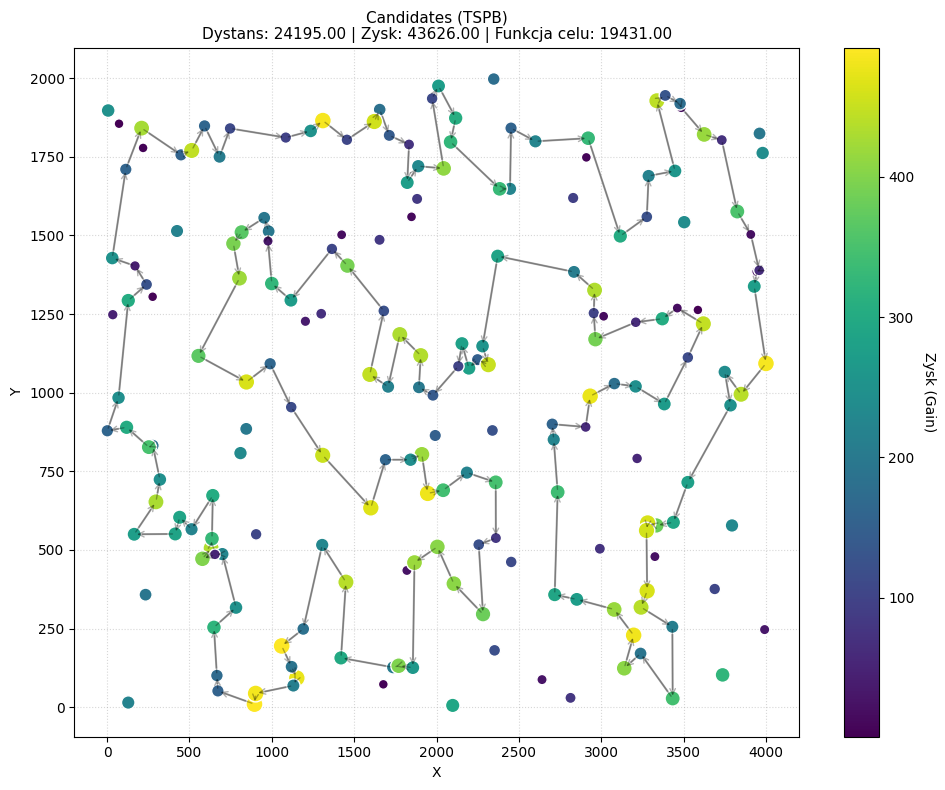

In [15]:
# plot_single_tsp_solution("Best_Standard_TSPA.csv.json", "Steepest Standard (TSPA)")
# plot_single_tsp_solution("Best_Standard_TSPB.csv.json", "Steepest Standard (TSPB)")


# plot_single_tsp_solution("Best_Heuristic_TSPA.csv.json", "2-regret (TSPA)")
# plot_single_tsp_solution("Best_Heuristic_TSPB.csv.json", "2-regret (TSPB)")

# plot_single_tsp_solution("Best_LM_TSPA.csv.json", "Steepest + Move List (TSPA)")
# plot_single_tsp_solution("Best_LM_TSPB.csv.json", "Steepest + Move List (TSPB)")

# plot_single_tsp_solution("Best_Candidates_TSPA.csv.json", "Candidates (TSPA)")
plot_single_tsp_solution("Best_Candidates_TSPB.csv.json", "Candidates (TSPB)")



In [16]:
import os

def plot_and_save_tsp(json_path, title, png_path, show=True):
    """Rysuje pojedynczy wykres TSP i zapisuje go jako PNG."""
    data = load_tsp_data(json_path)
    if not data:
        return

    fig, ax = plt.subplots(figsize=(10, 8))
    scatter = draw_tsp_on_ax(ax, data, title)

    cbar = fig.colorbar(scatter, ax=ax)
    cbar.set_label('Zysk (Gain)', rotation=270, labelpad=15)

    plt.tight_layout()

    os.makedirs(os.path.dirname(png_path) or ".", exist_ok=True)
    fig.savefig(png_path, dpi=150, bbox_inches='tight')
    print(f"Zapisano: {png_path}")

    if show:
        plt.show()
    else:
        plt.close(fig)


Zapisano: zad4_png/Best_MSLS_TSPA.png


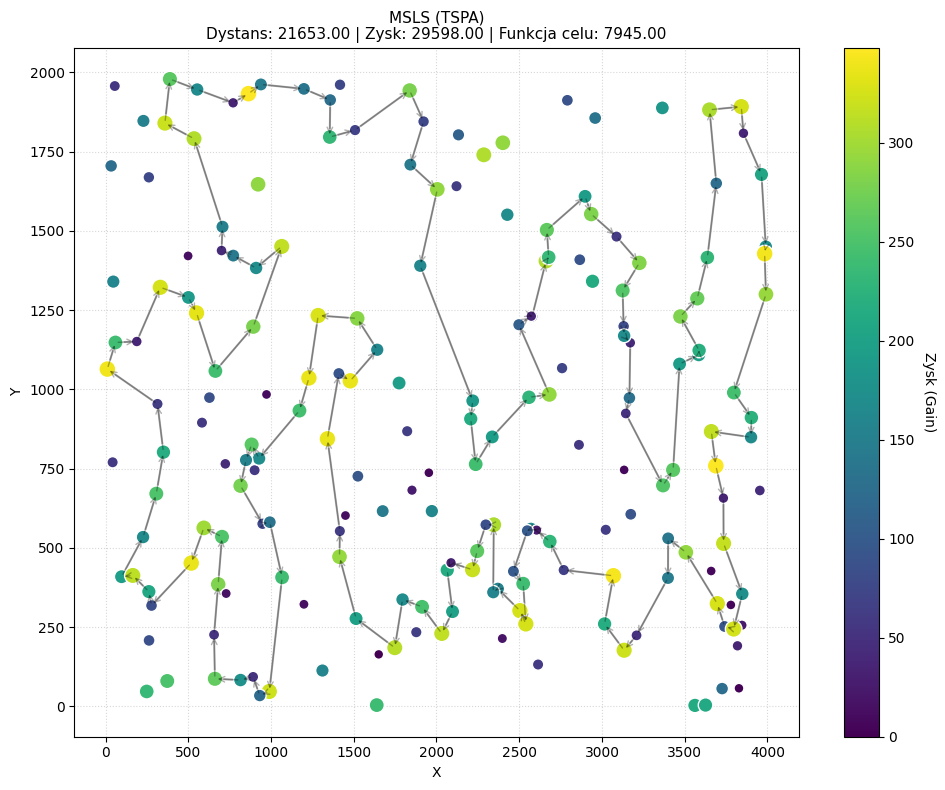

Zapisano: zad4_png/Best_MSLS_TSPB.png


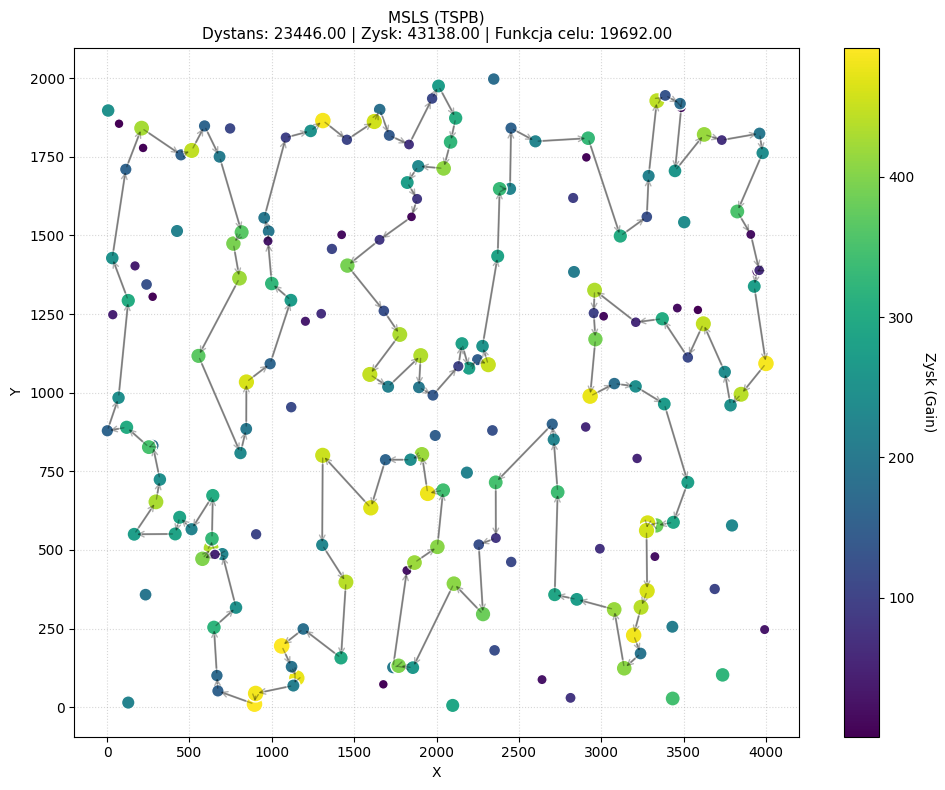

Zapisano: zad4_png/Best_ILS_TSPA.png


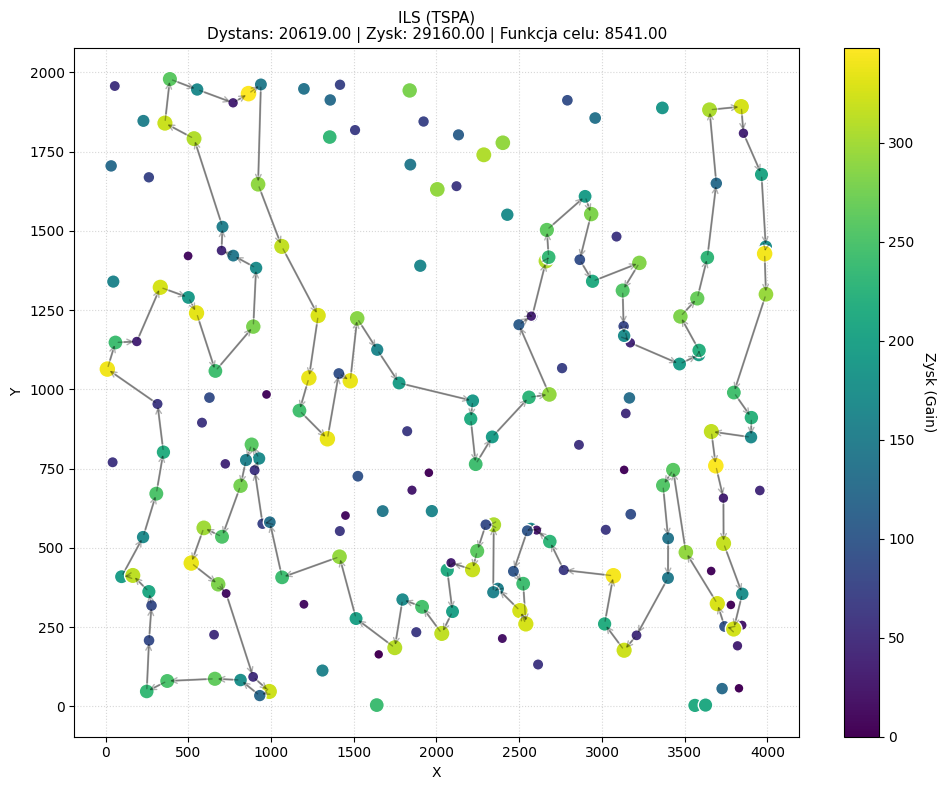

Zapisano: zad4_png/Best_ILS_TSPB.png


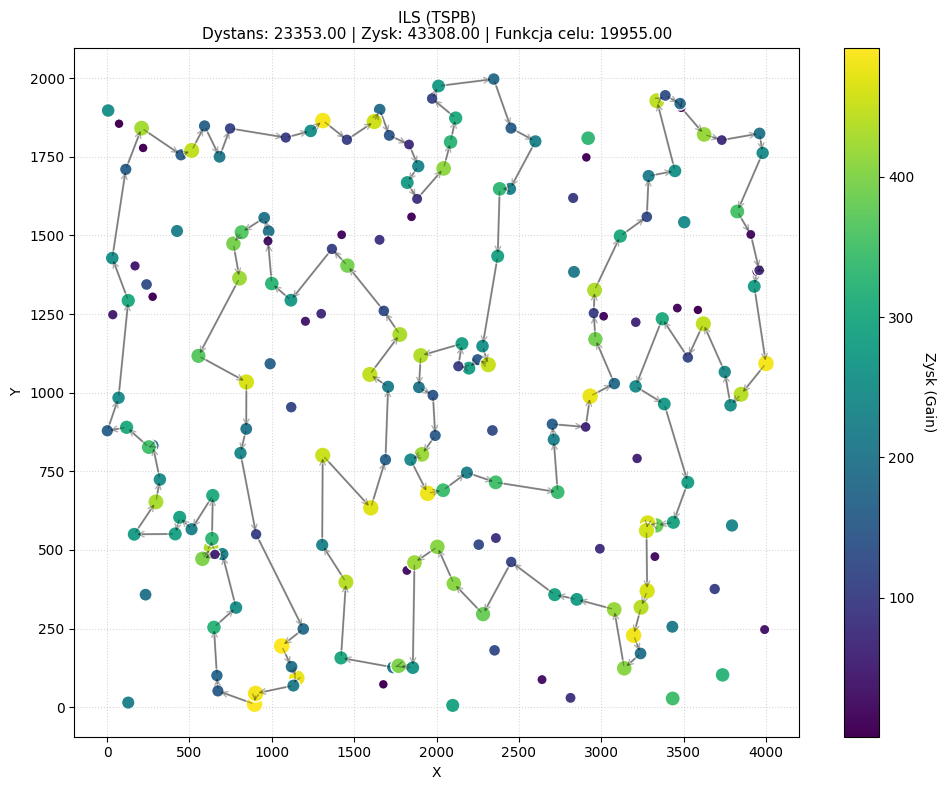

Zapisano: zad4_png/Best_LNS_TSPA.png


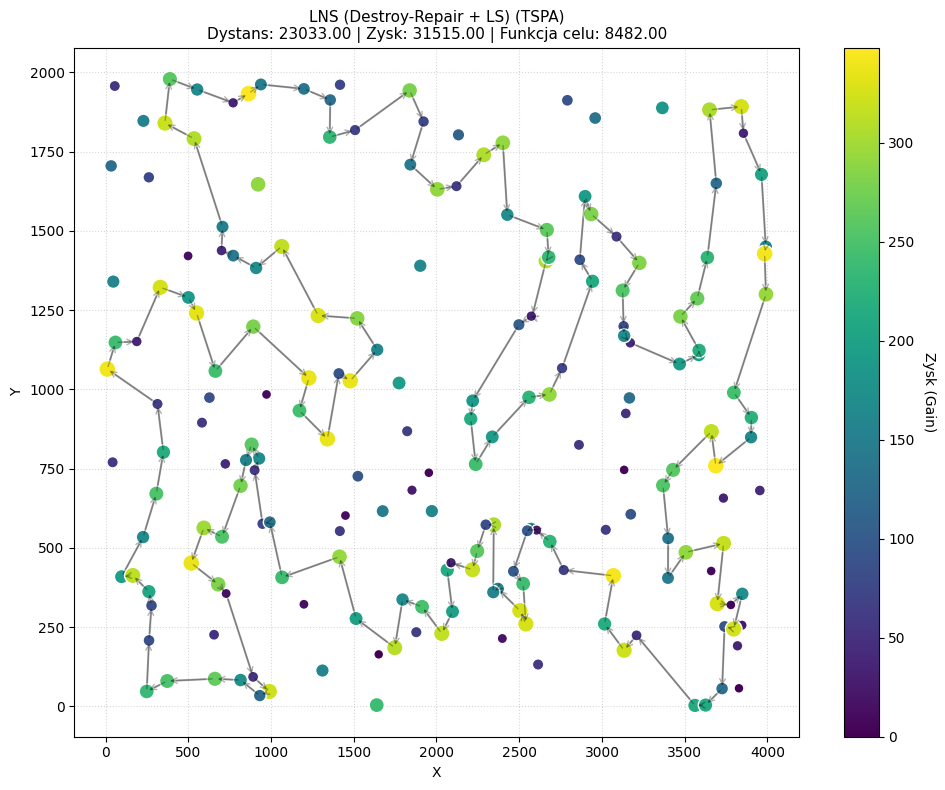

Zapisano: zad4_png/Best_LNS_TSPB.png


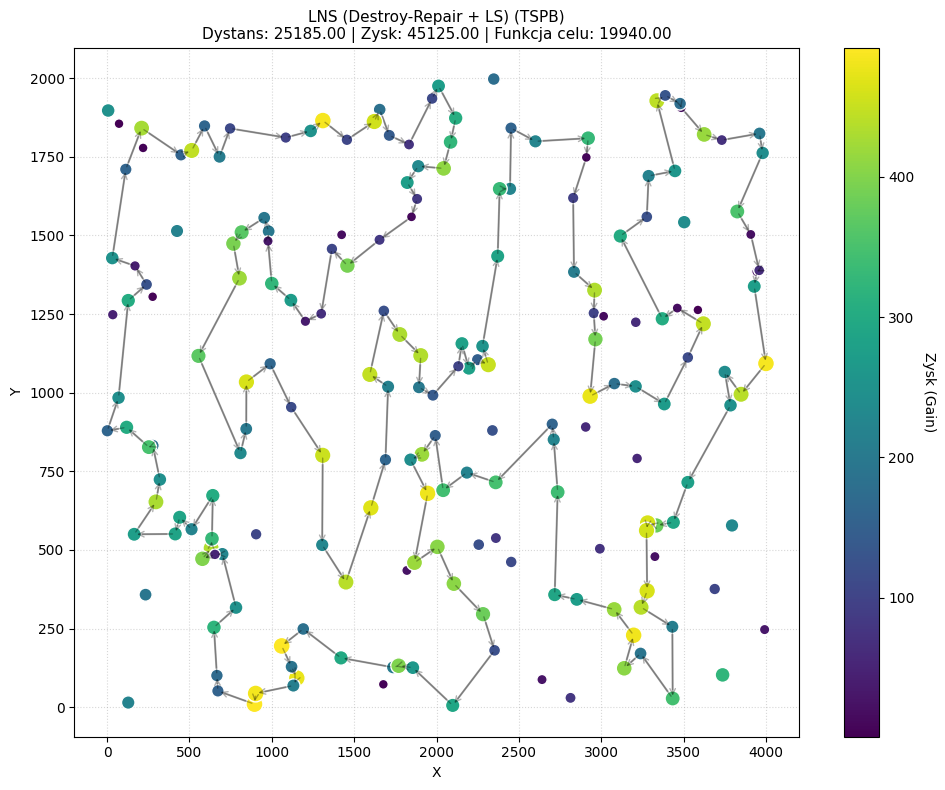

Zapisano: zad4_png/Best_LNSa_TSPA.png


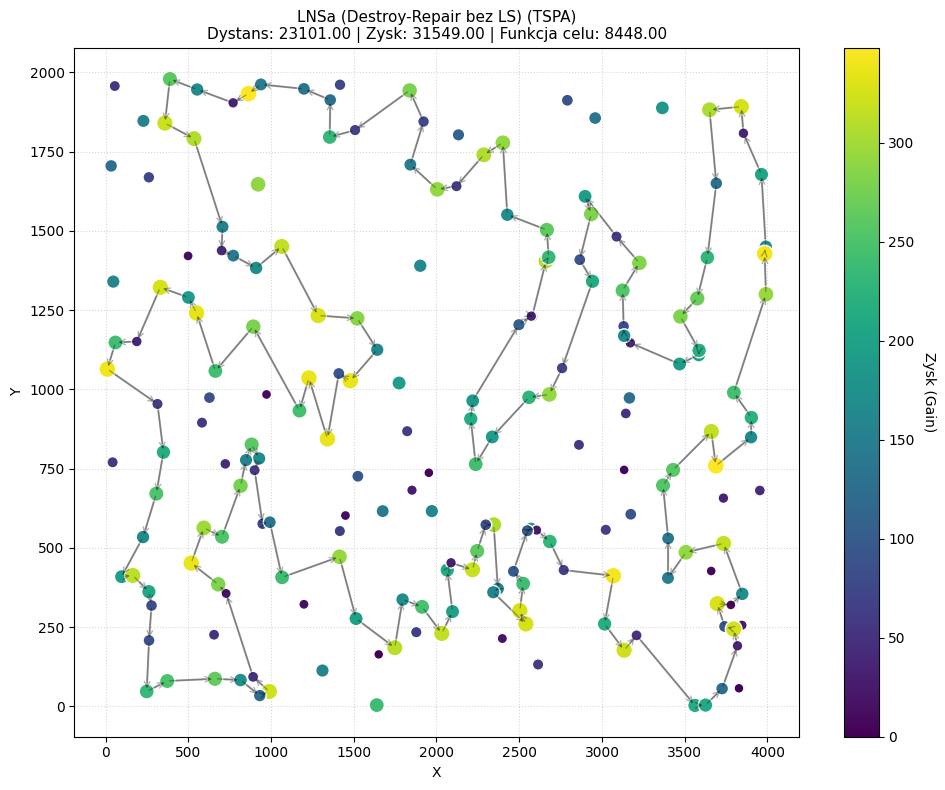

Zapisano: zad4_png/Best_LNSa_TSPB.png


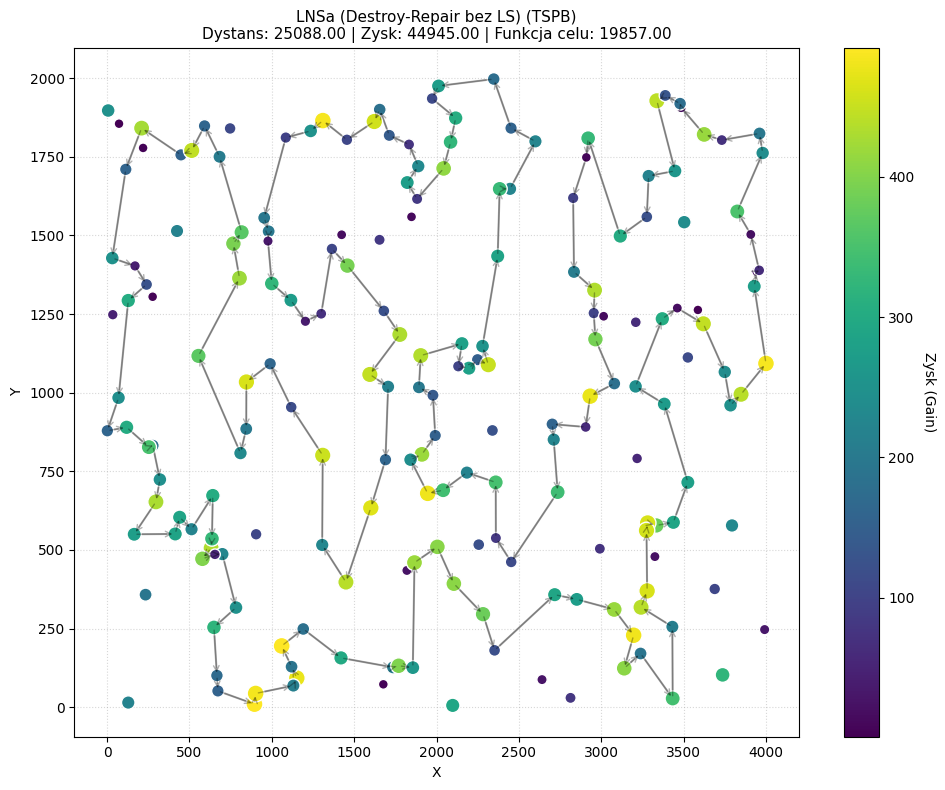

In [17]:
# === ZADANIE 4: MSLS, ILS, LNS, LNSa - wizualizacja i zapis do PNG ===

zad4_methods = [
    ("MSLS", "MSLS"),
    ("ILS",  "ILS"),
    ("LNS",  "LNS (Destroy-Repair + LS)"),
    ("LNSa", "LNSa (Destroy-Repair bez LS)"),
]
instances = ["TSPA", "TSPB"]

os.makedirs("zad4_png", exist_ok=True)

for method_id, pretty in zad4_methods:
    for inst in instances:
        json_path = f"Best_{method_id}_{inst}.csv.json"
        png_path  = f"zad4_png/Best_{method_id}_{inst}.png"
        title     = f"{pretty} ({inst})"
        plot_and_save_tsp(json_path, title, png_path, show=True)


## Zadanie 5 – Testy globalnej wypukłości

Dla każdej instancji (TSPA, TSPB):
- **1000 losowych optyma lokalnych** (zachłanne LocalSearch z losowego startu)
- **Bardzo dobre rozwiązanie** wygenerowane metodą LNS

Dla każdego optimum lokalnego policzone zostało:
1. Podobieństwo do najlepszego rozwiązania (wierzchołki i krawędzie)
2. Średnie podobieństwo do pozostałych 999 optyma lokalnych (wierzchołki i krawędzie)

Oś X = wartość funkcji celu, oś Y = (średnie) podobieństwo. Wartość korelacji Pearsona *r* pokazana na każdym wykresie.

Zapisano: zad5_png/TSPA_convexity.png


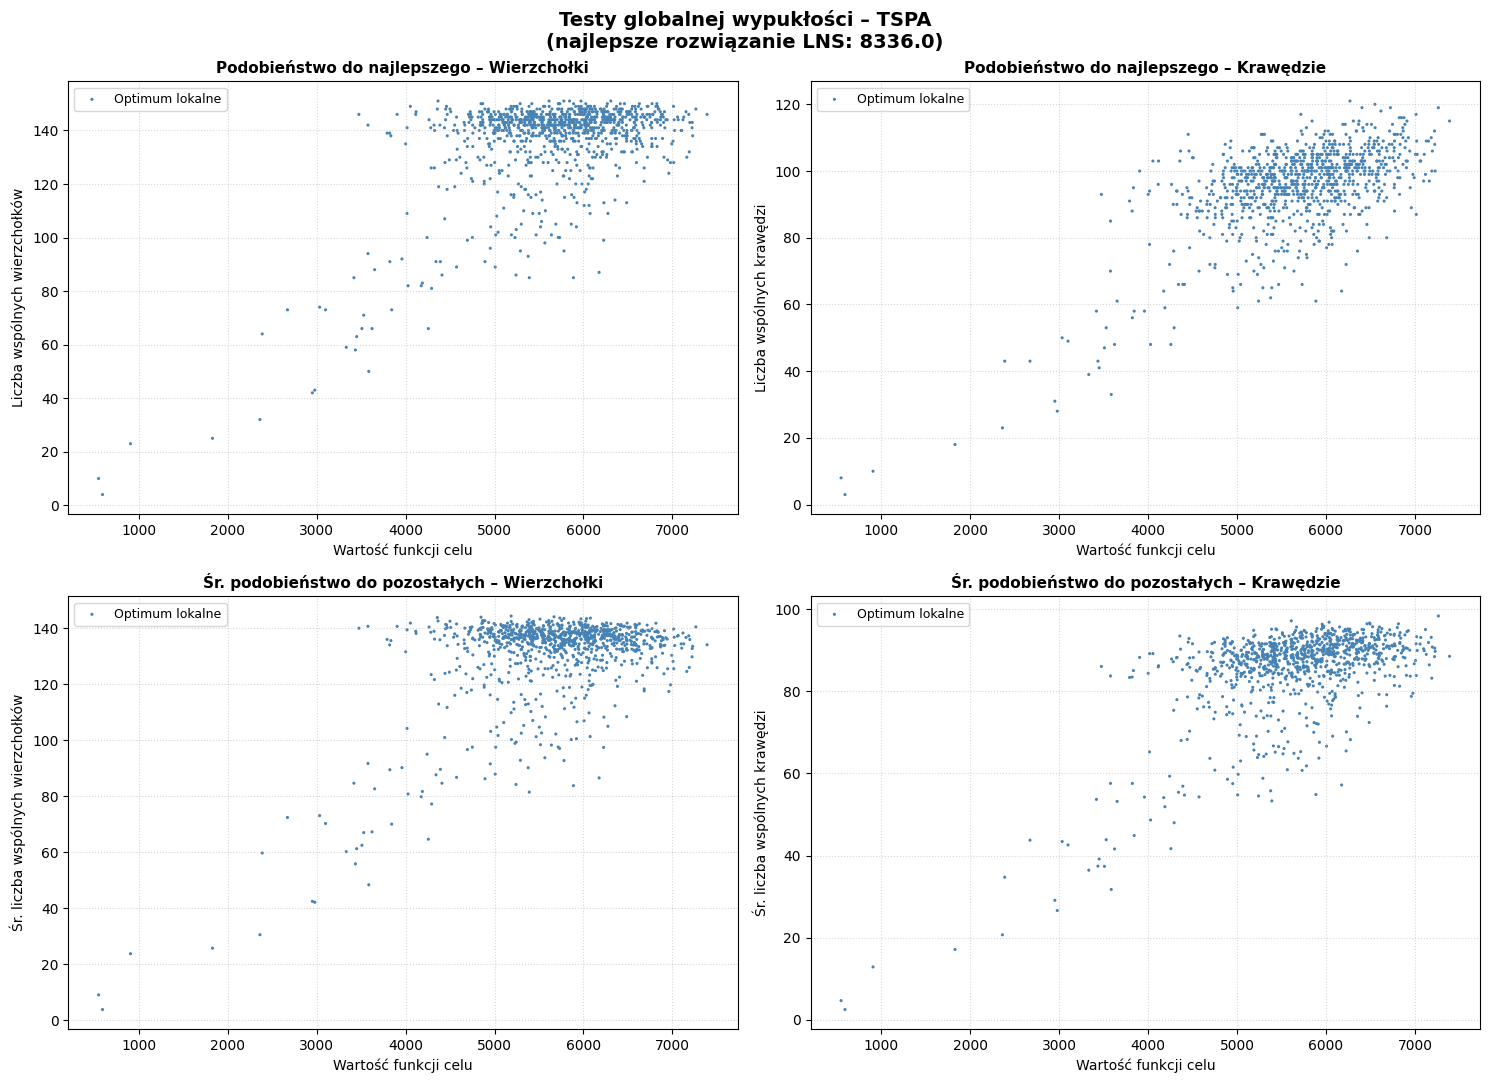

Zapisano: zad5_png/TSPB_convexity.png


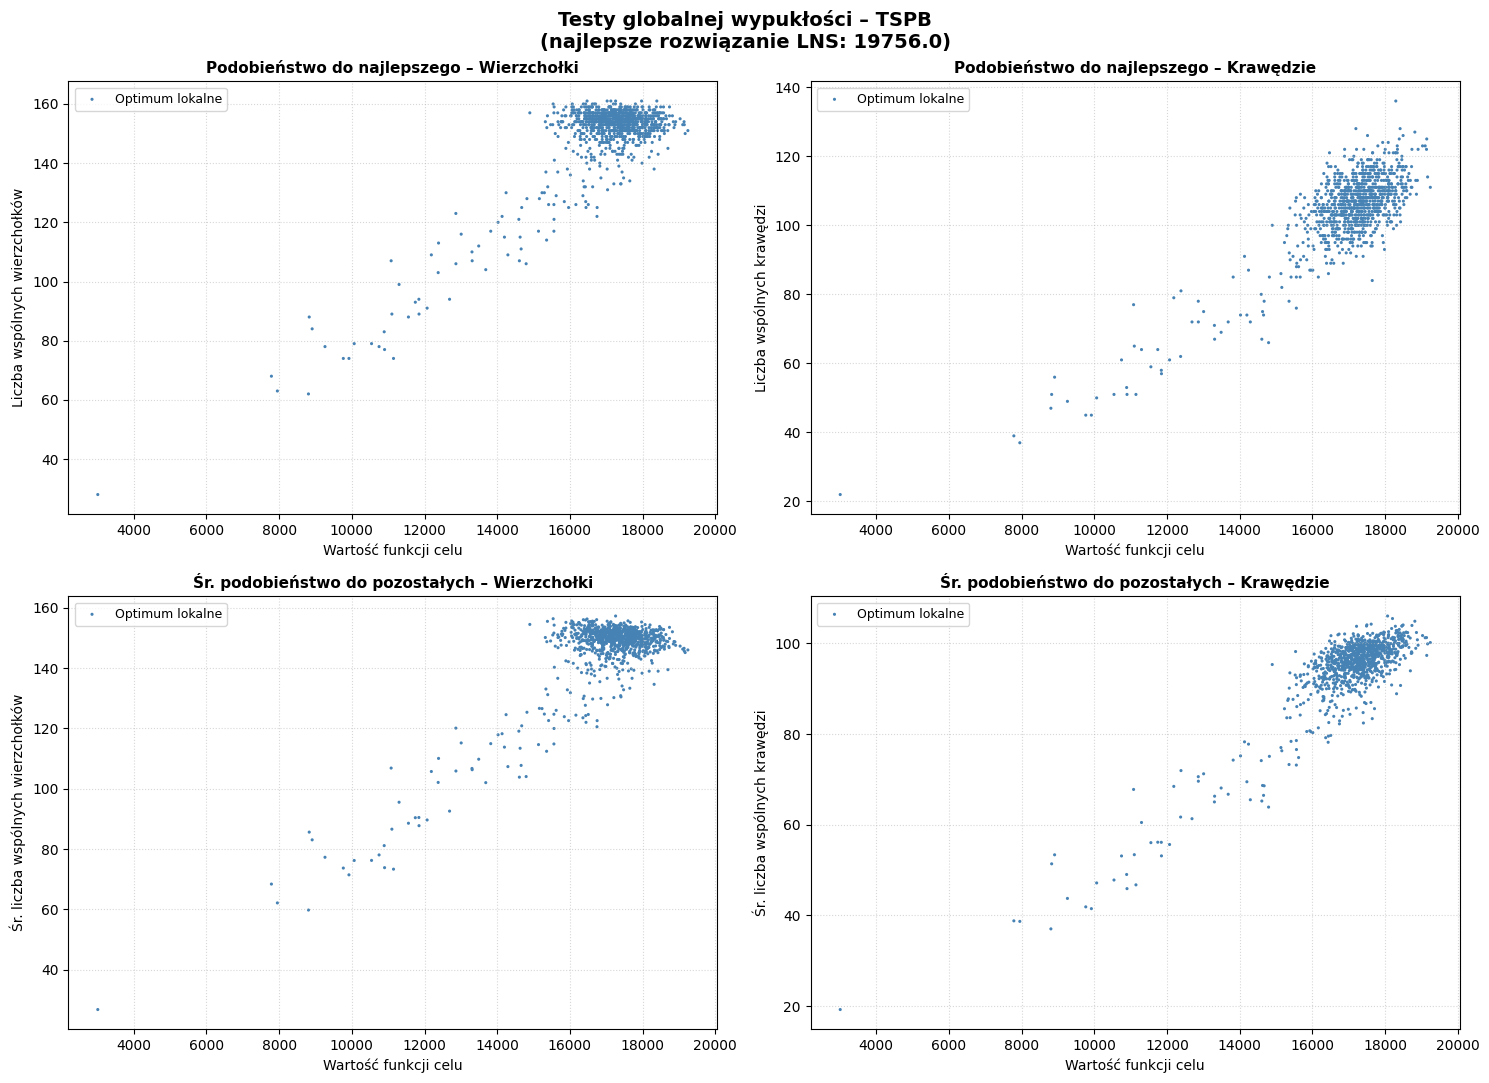


=== Współczynniki korelacji Pearsona (r) ===


,best score,sim to best vertices,sim to best edges,avg sim others vertices,avg sim others edges
instance,,,,,
TSPA,8336.0,0.5292,0.6348,0.5058,0.5944
TSPB,19756.0,0.8179,0.8270,0.8110,0.8858


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ---------------------------------------------------------------------------
# Wczytywanie
# ---------------------------------------------------------------------------

def load_zad5_data(instance_filename):
    """Wczytuje dane optyma lokalnych z pliku zad5_{instance_filename}.csv"""
    path = f'zad5_{instance_filename}.csv'
    return pd.read_csv(path, sep=';')

def load_zad5_summary():
    """Wczytuje plik podsumowania z korelacjami (jeden wiersz na instancję)."""
    return pd.read_csv('zad5_summary.csv', sep=';')

# ---------------------------------------------------------------------------
# Rysowanie jednej instancji (siatka 2x2)
# ---------------------------------------------------------------------------

_ZAD5_PLOTS = [
    ('sim_to_best_vertices',    'corr_sim_to_best_vertices',
     'Podobieństwo do najlepszego',        'Wierzchołki',
     'Liczba wspólnych wierzchołków'),
    ('sim_to_best_edges',       'corr_sim_to_best_edges',
     'Podobieństwo do najlepszego',        'Krawędzie',
     'Liczba wspólnych krawędzi'),
    ('avg_sim_others_vertices', 'corr_avg_sim_others_vertices',
     'Śr. podobieństwo do pozostałych',   'Wierzchołki',
     'Śr. liczba wspólnych wierzchołków'),
    ('avg_sim_others_edges',    'corr_avg_sim_others_edges',
     'Śr. podobieństwo do pozostałych',   'Krawędzie',
     'Śr. liczba wspólnych krawędzi'),
]

def plot_zad5_instance(instance_filename, df, summary_df, save_dir='zad5_png'):
    scores = df['score'].values

    fig, axes = plt.subplots(2, 2, figsize=(15, 11))
    axes = axes.flatten()

    row = summary_df[summary_df['instance'] == instance_filename]

    for ax, (col, corr_key, row_label, col_label, ylabel) in zip(axes, _ZAD5_PLOTS):
        sim = df[col].values

        # Korelacja z pliku podsumowania lub policz bezpośrednio
        if not row.empty and corr_key in row.columns:
            r = float(row[corr_key].iloc[0])
        else:
            r = float(np.corrcoef(scores, sim)[0, 1])

        # Punkty
        ax.scatter(scores, sim, s=5, alpha=1.0, color='steelblue',
                   edgecolors='none', label=f'Optimum lokalne')

        ax.set_title(f'{row_label} – {col_label}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Wartość funkcji celu', fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.legend(fontsize=9, loc='upper left')
        ax.grid(True, linestyle=':', alpha=0.5)

    best = float(row['best_score'].iloc[0]) if not row.empty else float('nan')
    name = instance_filename.replace('.csv', '')
    fig.suptitle(
        f'Testy globalnej wypukłości – {name}\n'
        f'(najlepsze rozwiązanie LNS: {best:.1f})',
        fontsize=14, fontweight='bold'
    )
    plt.tight_layout()

    os.makedirs(save_dir, exist_ok=True)
    out = f'{save_dir}/{name}_convexity.png'
    fig.savefig(out, dpi=150, bbox_inches='tight')
    print(f'Zapisano: {out}')
    plt.show()

# ---------------------------------------------------------------------------
# Uruchomienie dla obu instancji
# ---------------------------------------------------------------------------

try:
    summary_df = load_zad5_summary()
except FileNotFoundError:
    print('Brak pliku zad5_summary.csv – uruchom najpierw RunTask5Experiment w C++.')
    summary_df = pd.DataFrame()

for inst in ['TSPA.csv', 'TSPB.csv']:
    try:
        df = load_zad5_data(inst)
        plot_zad5_instance(inst, df, summary_df)
    except FileNotFoundError:
        print(f'Brak pliku zad5_{inst}.csv – pomiń.')

# ---------------------------------------------------------------------------
# Tabela podsumowania korelacji
# ---------------------------------------------------------------------------

if not summary_df.empty:
    print('\n=== Współczynniki korelacji Pearsona (r) ===')
    disp = summary_df.copy()
    disp['instance'] = disp['instance'].str.replace('.csv', '', regex=False)
    disp = disp.set_index('instance')
    disp.columns = [c.replace('corr_', '').replace('_', ' ') for c in disp.columns]
    display(disp.round(4))

## Zadanie 6 – Hybrydowy Algorytm Ewolucyjny (HAE)

Zapisano: zad6_png/Best_HAE_Op1_TSPA.png


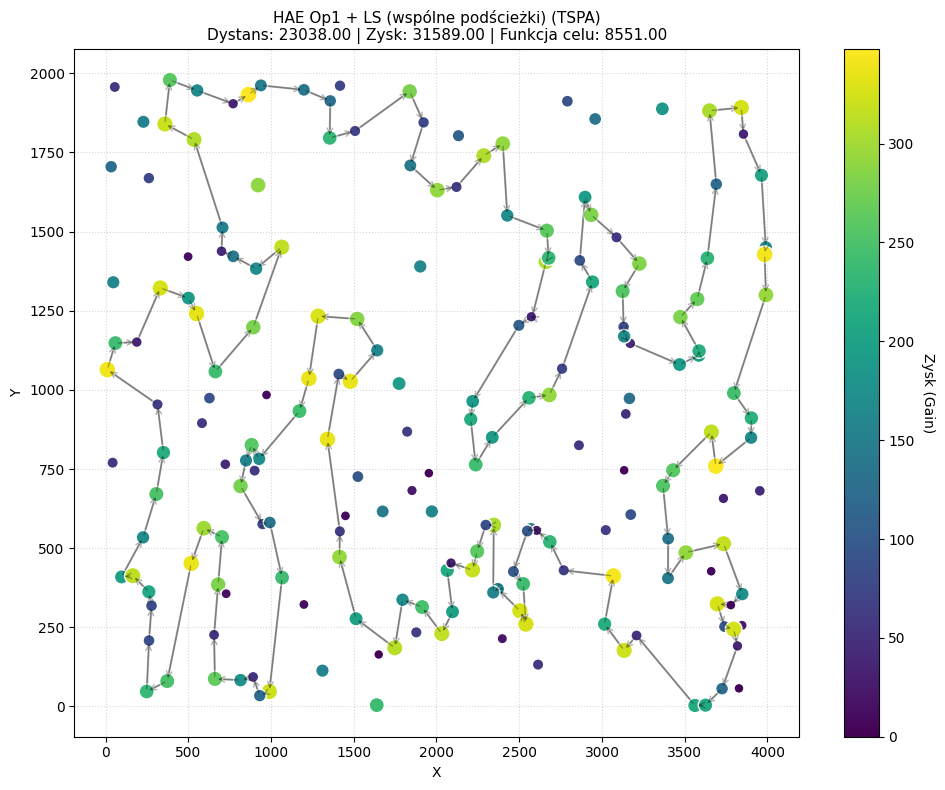

Zapisano: zad6_png/Best_HAE_Op1_TSPB.png


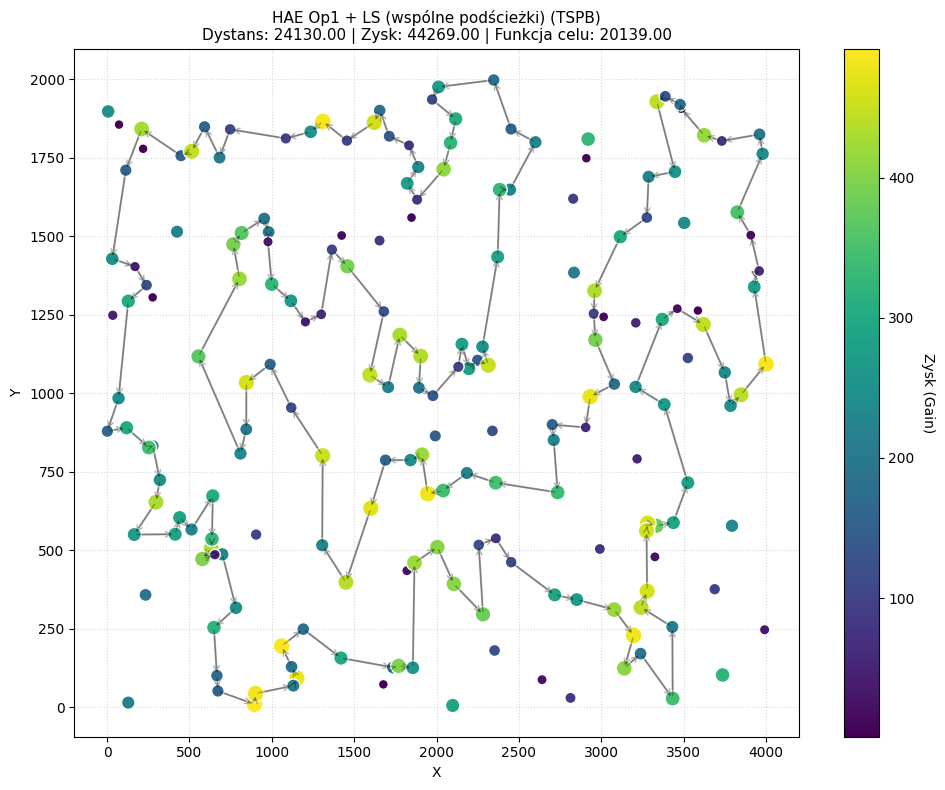

Zapisano: zad6_png/Best_HAE_Op2_LS_TSPA.png


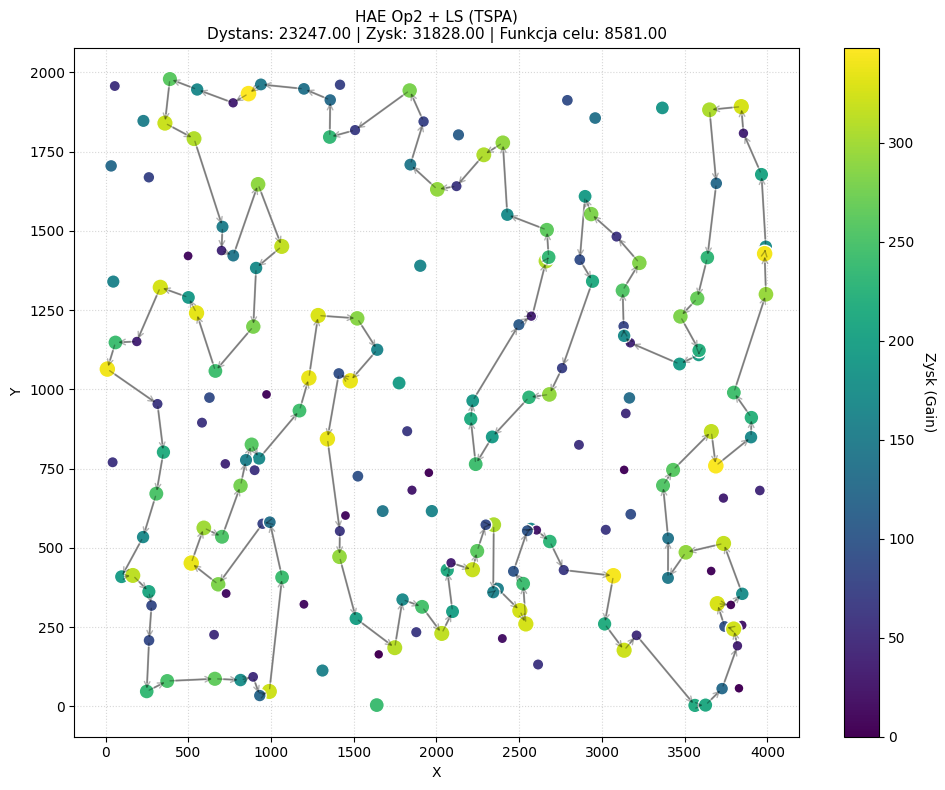

Zapisano: zad6_png/Best_HAE_Op2_LS_TSPB.png


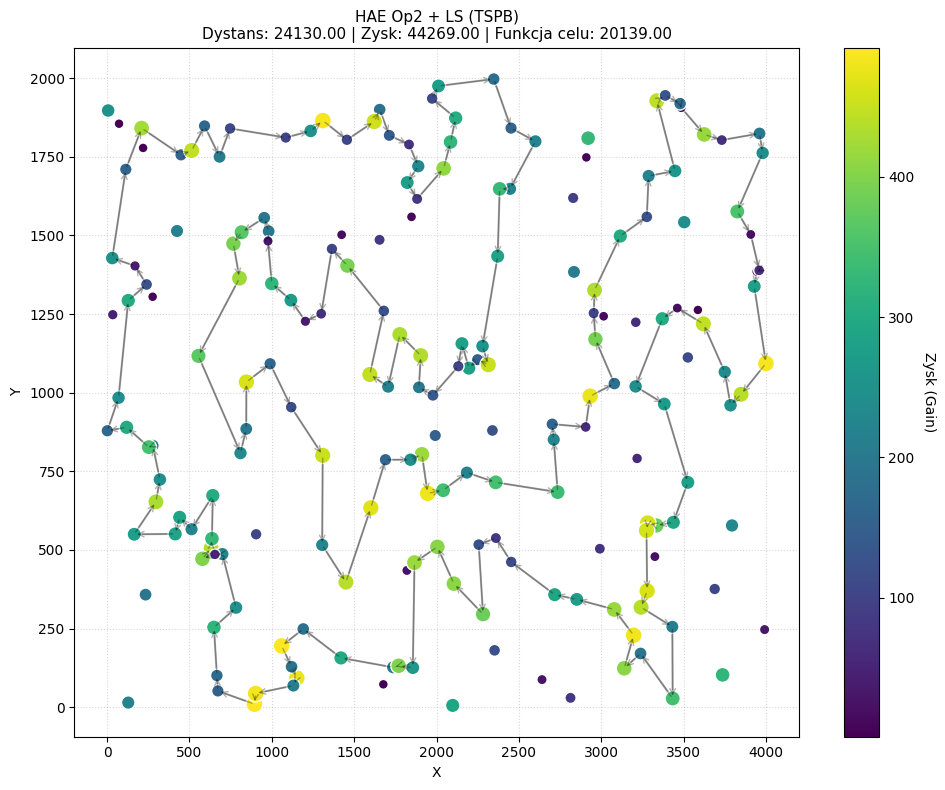

Zapisano: zad6_png/Best_HAE_Op2_noLS_TSPA.png


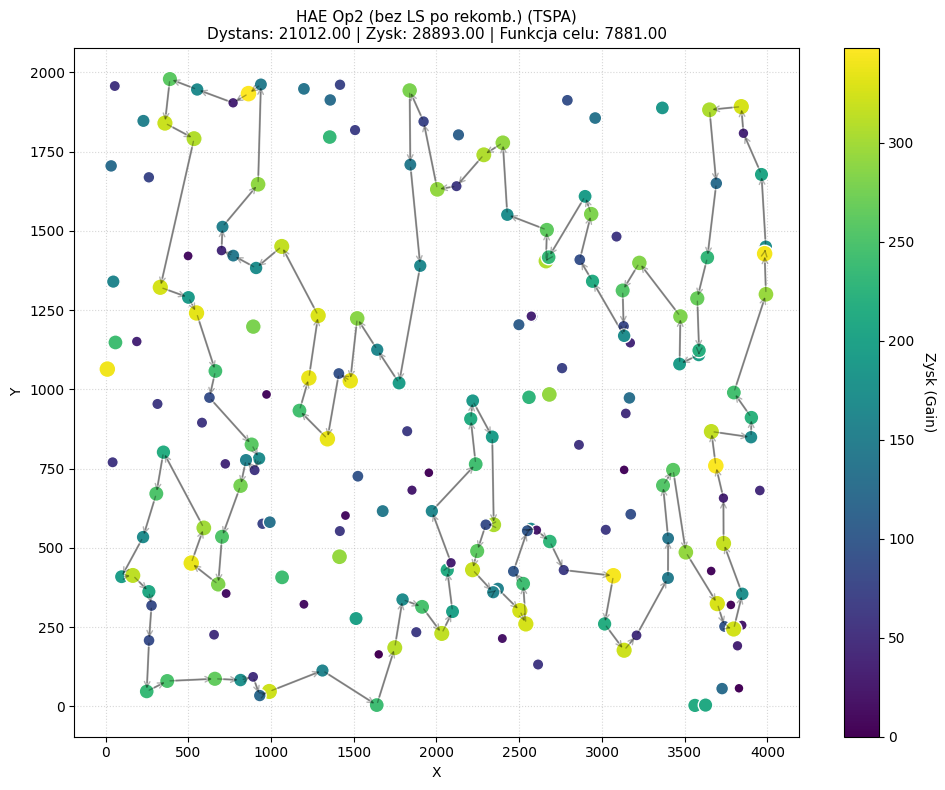

Zapisano: zad6_png/Best_HAE_Op2_noLS_TSPB.png


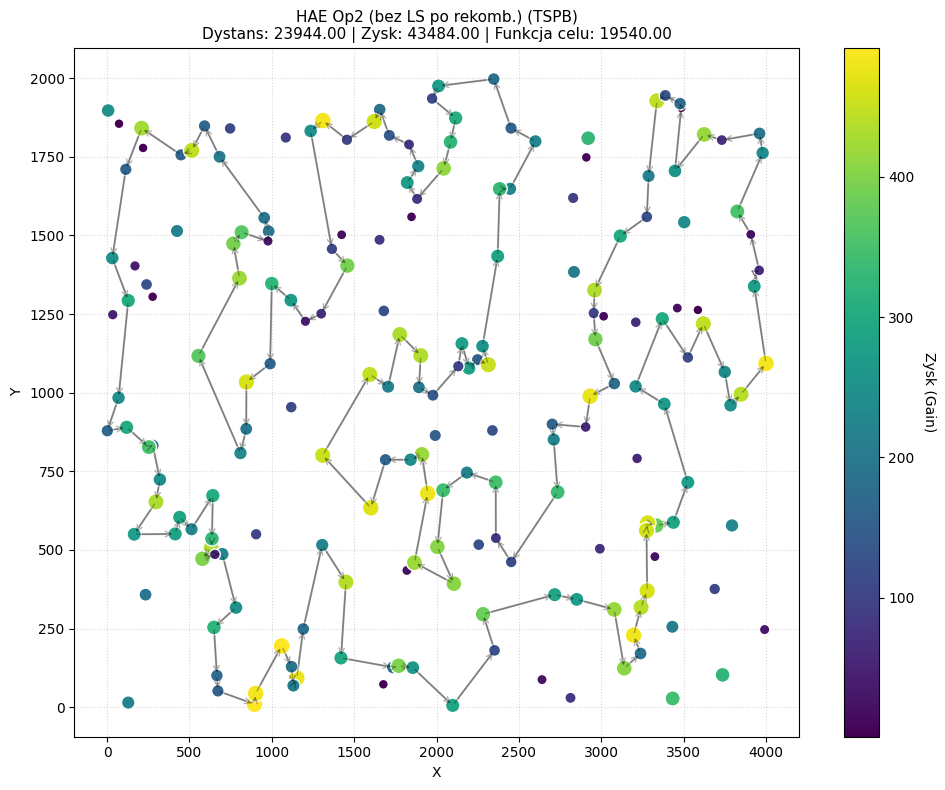

Zapisano: zad6_png/Best_HAE_Op3_LS_TSPA.png


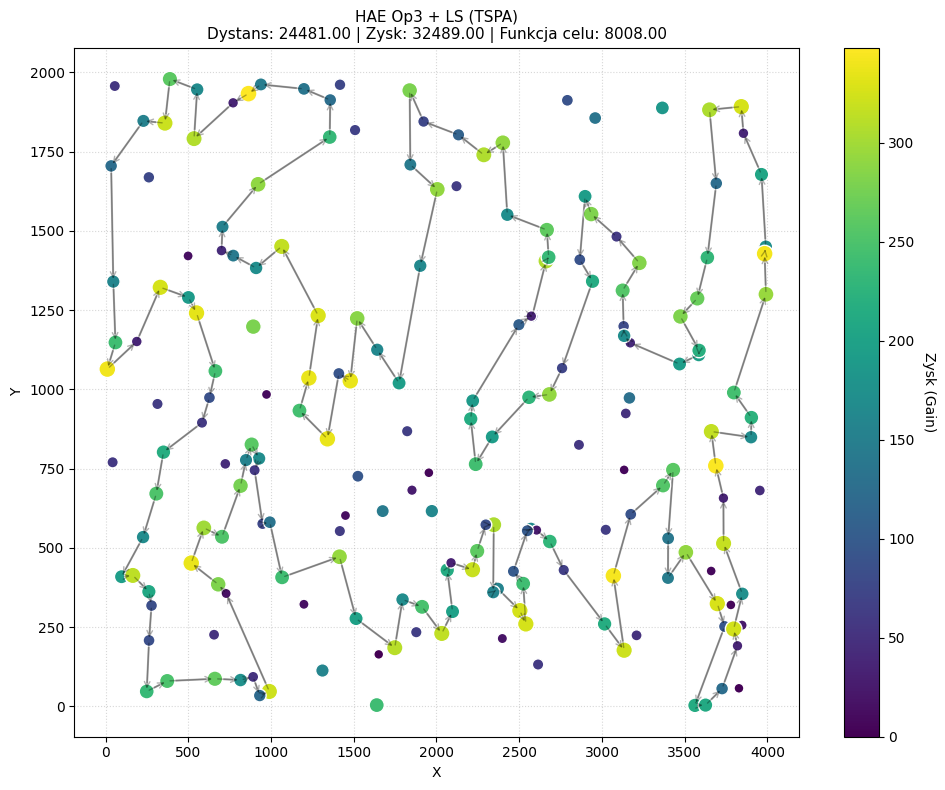

Zapisano: zad6_png/Best_HAE_Op3_LS_TSPB.png


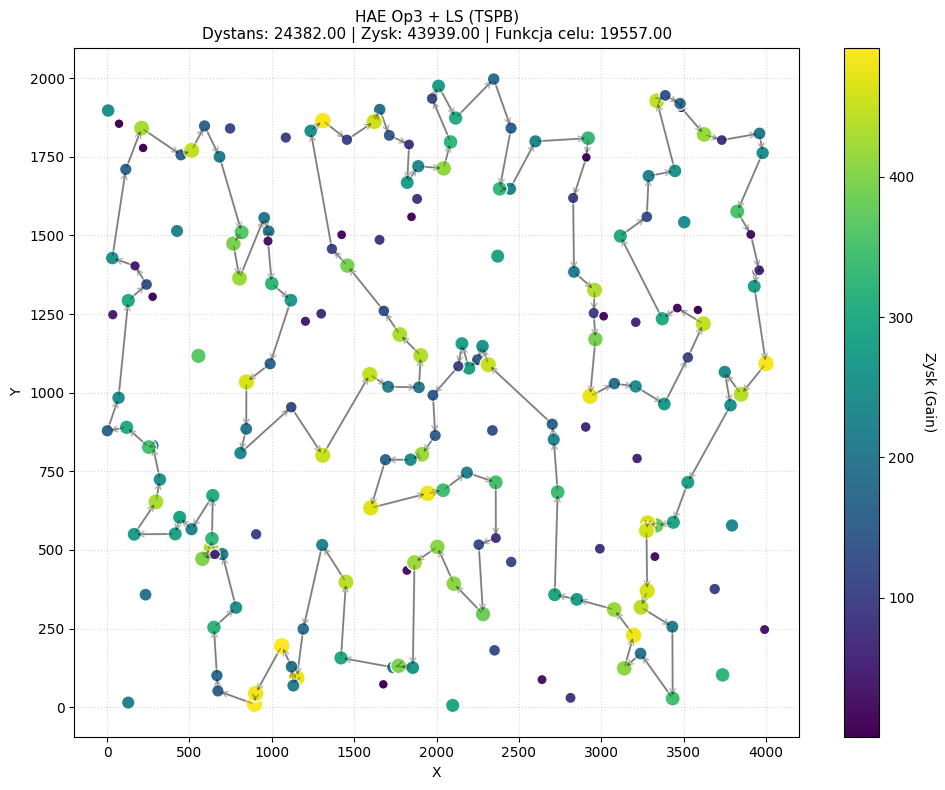

Zapisano: zad6_png/Best_HAE_Op3_noLS_TSPA.png


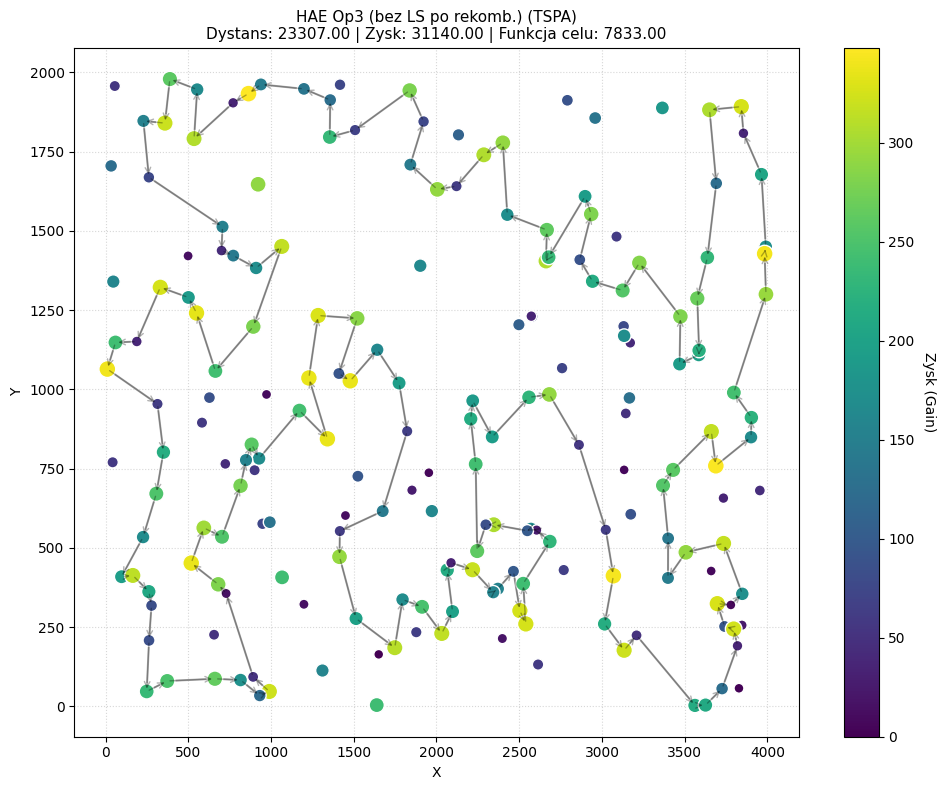

Zapisano: zad6_png/Best_HAE_Op3_noLS_TSPB.png


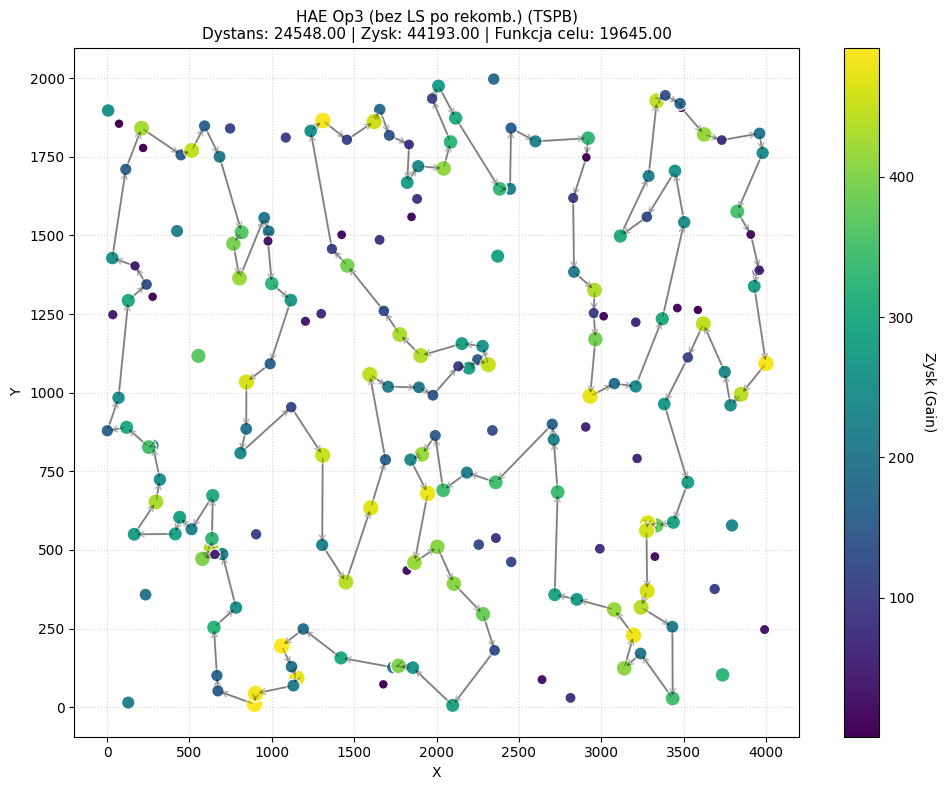

Zapisano: zad6_png/Best_MSLS_z6_TSPA.png


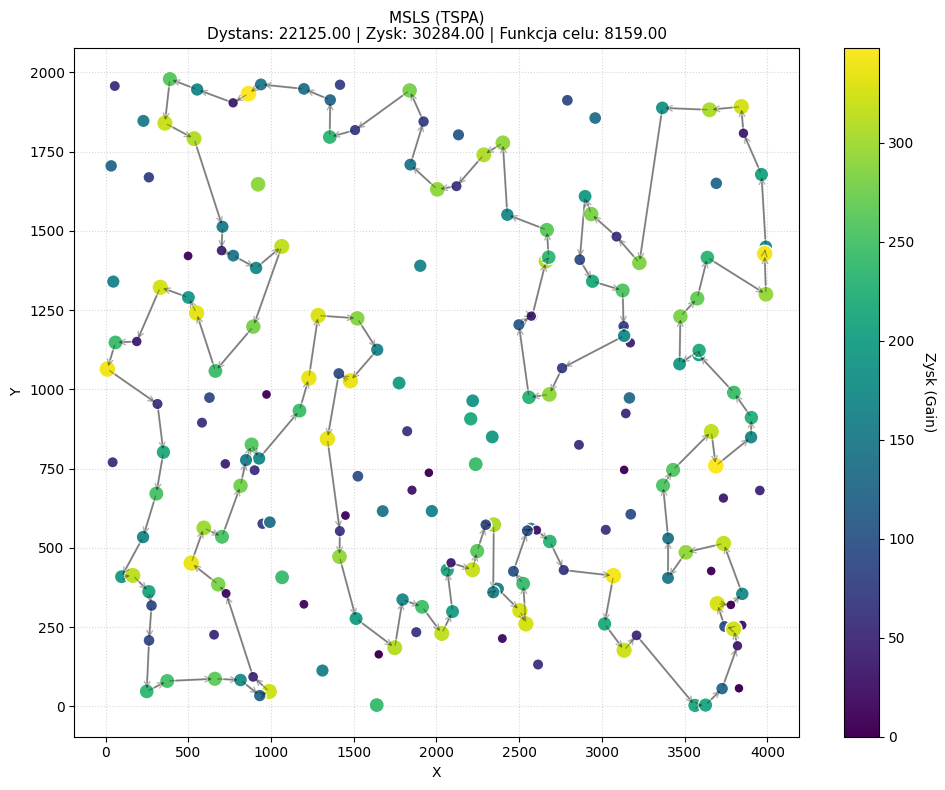

Zapisano: zad6_png/Best_MSLS_z6_TSPB.png


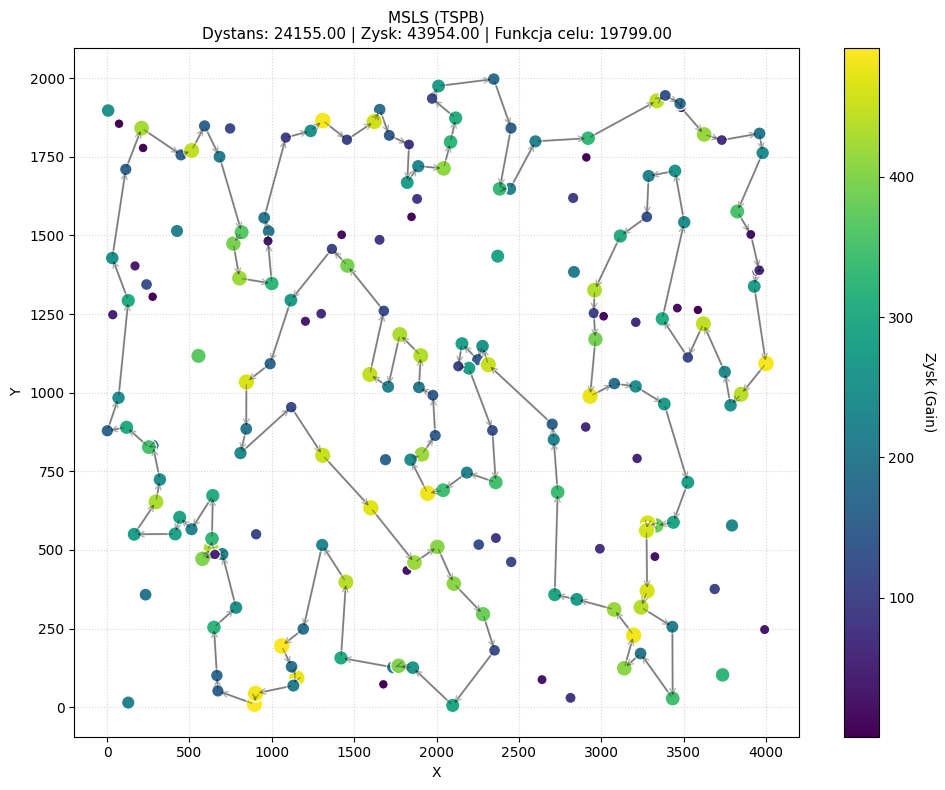

Zapisano: zad6_png/Best_ILS_z6_TSPA.png


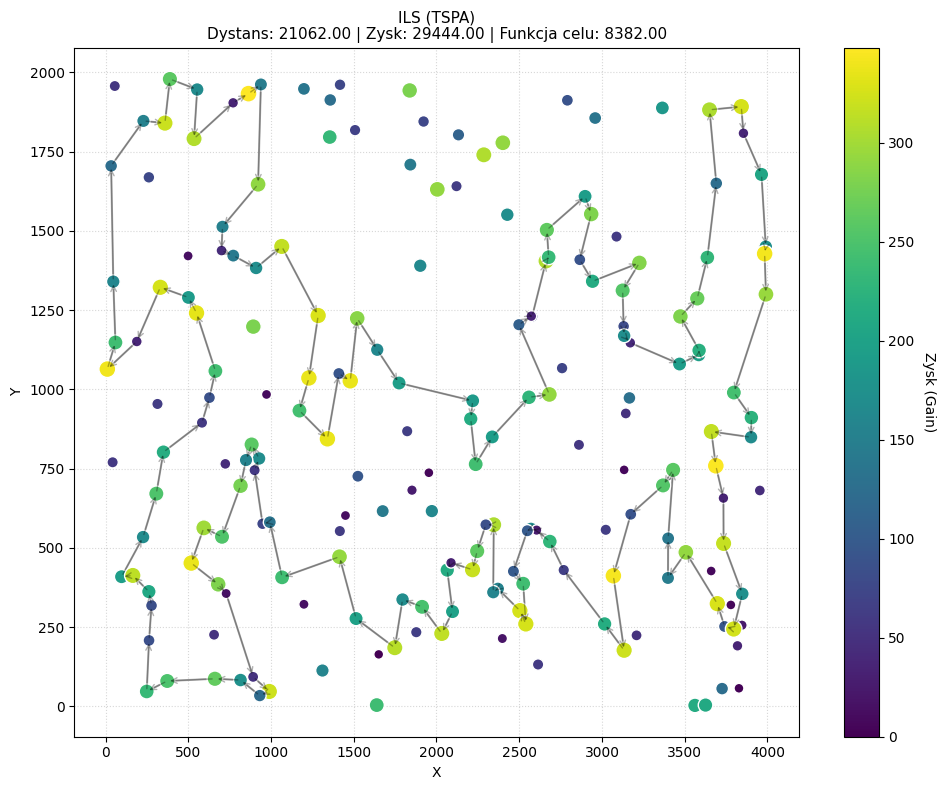

Zapisano: zad6_png/Best_ILS_z6_TSPB.png


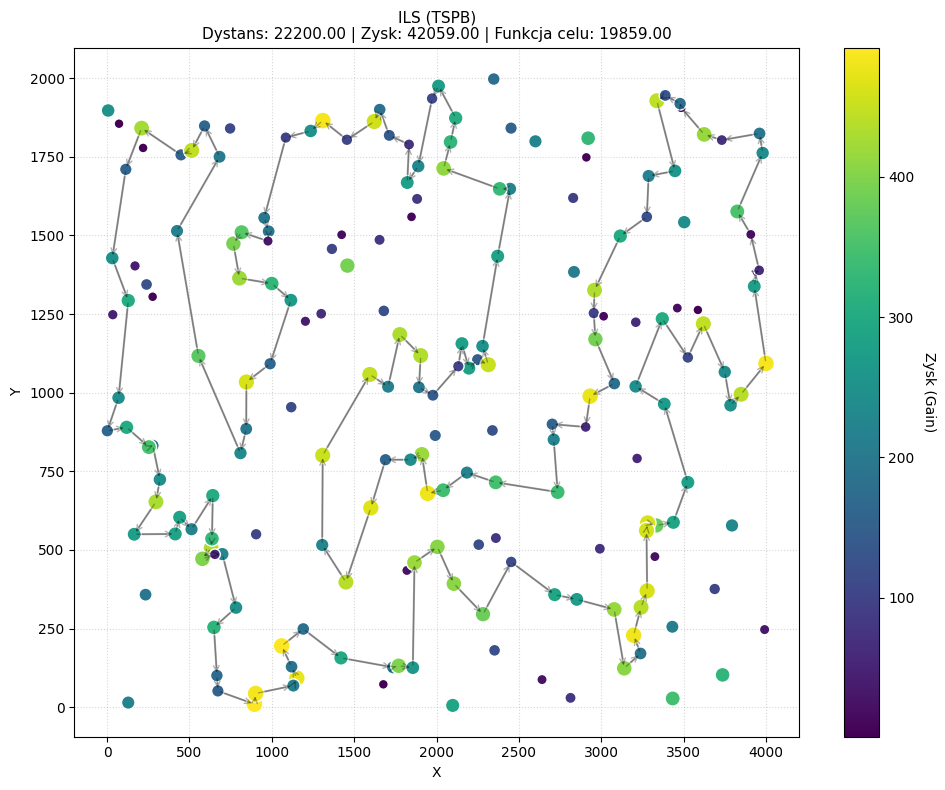

Zapisano: zad6_png/Best_LNS_z6_TSPA.png


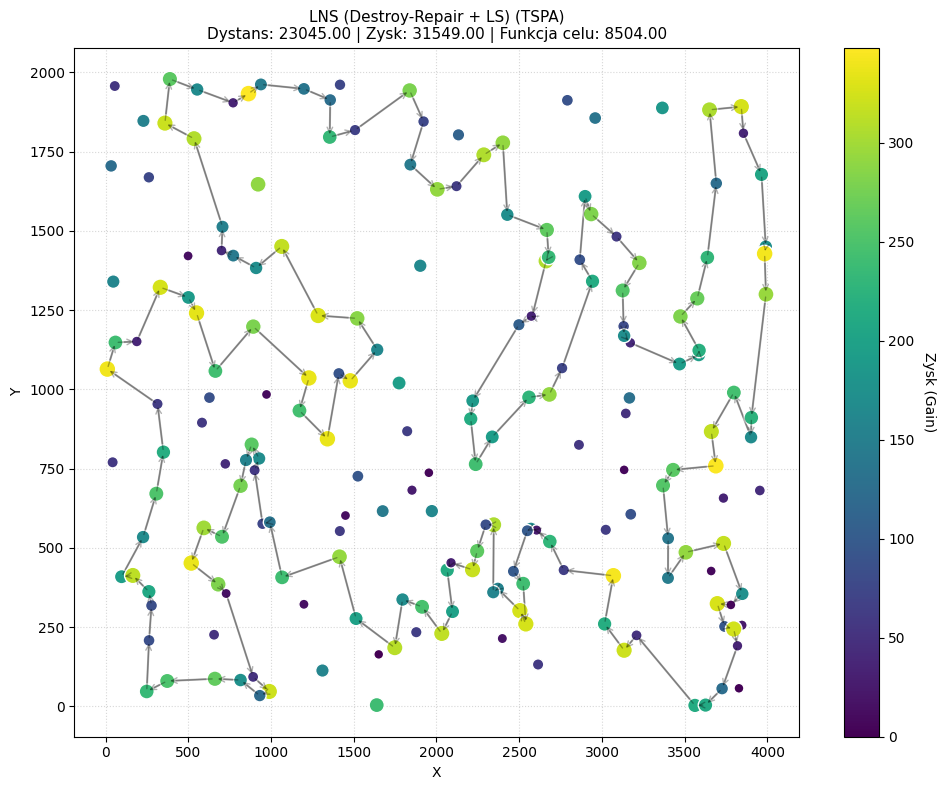

Zapisano: zad6_png/Best_LNS_z6_TSPB.png


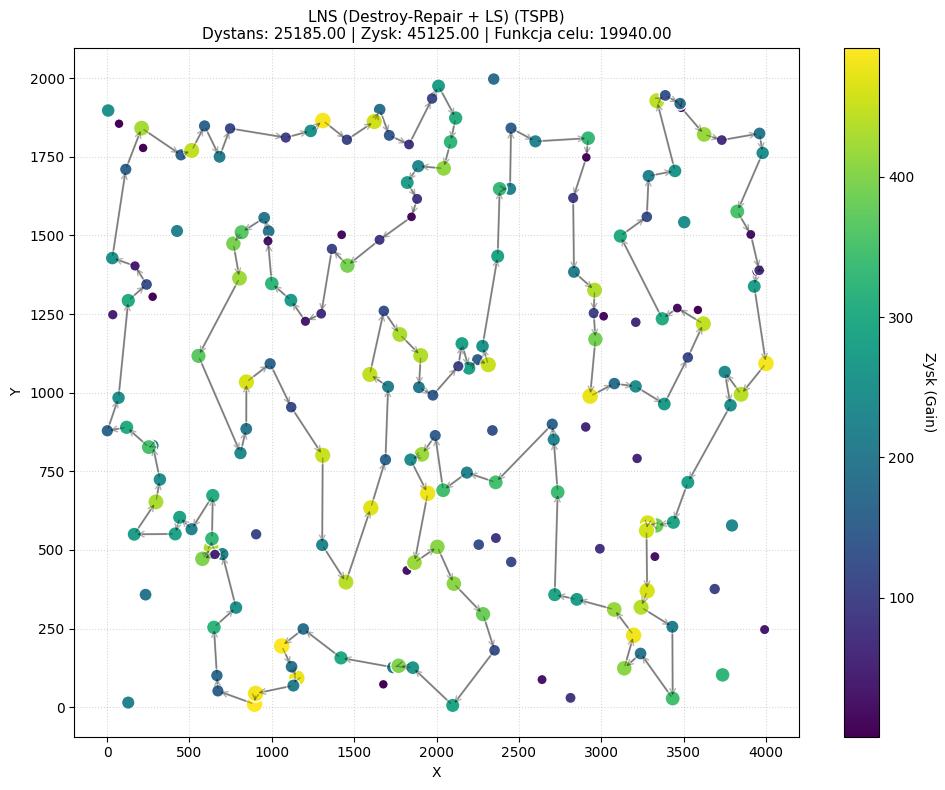

Zapisano: zad6_png/Best_Heur_z6_TSPA.png


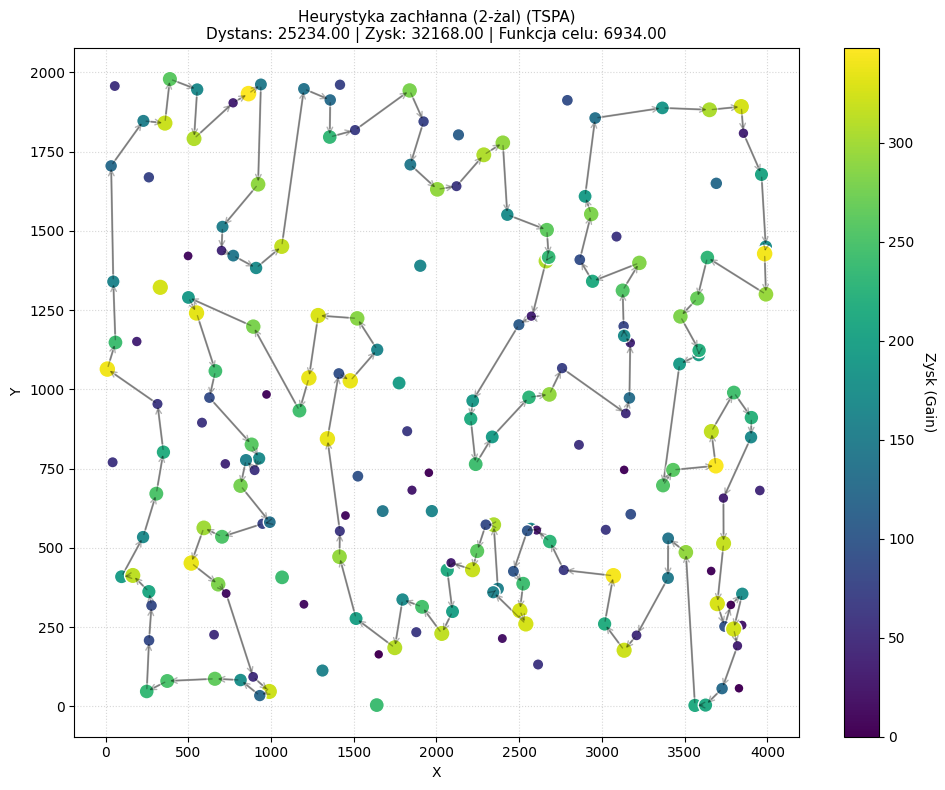

Zapisano: zad6_png/Best_Heur_z6_TSPB.png


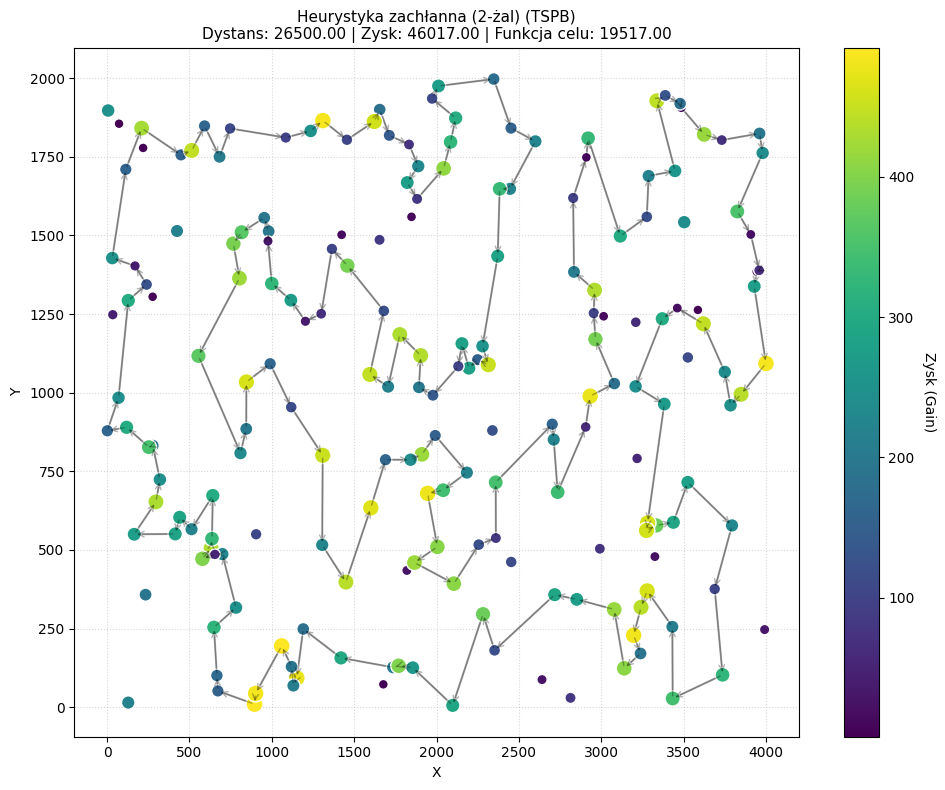

Zapisano: zad6_png/Best_BaseLS_z6_TSPA.png


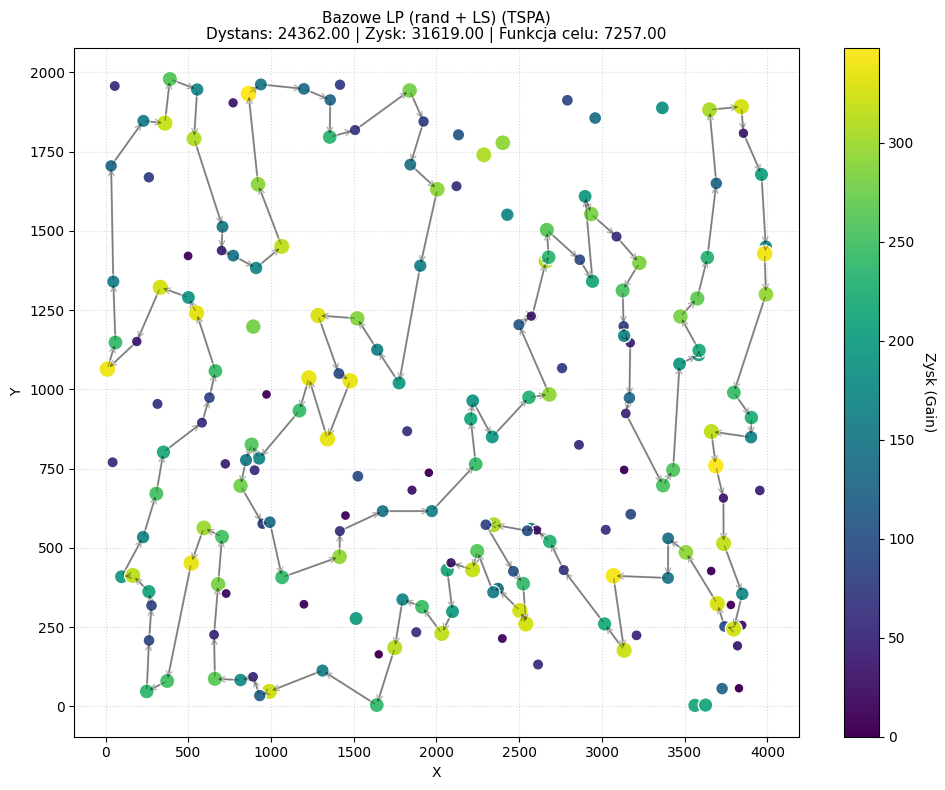

Zapisano: zad6_png/Best_BaseLS_z6_TSPB.png


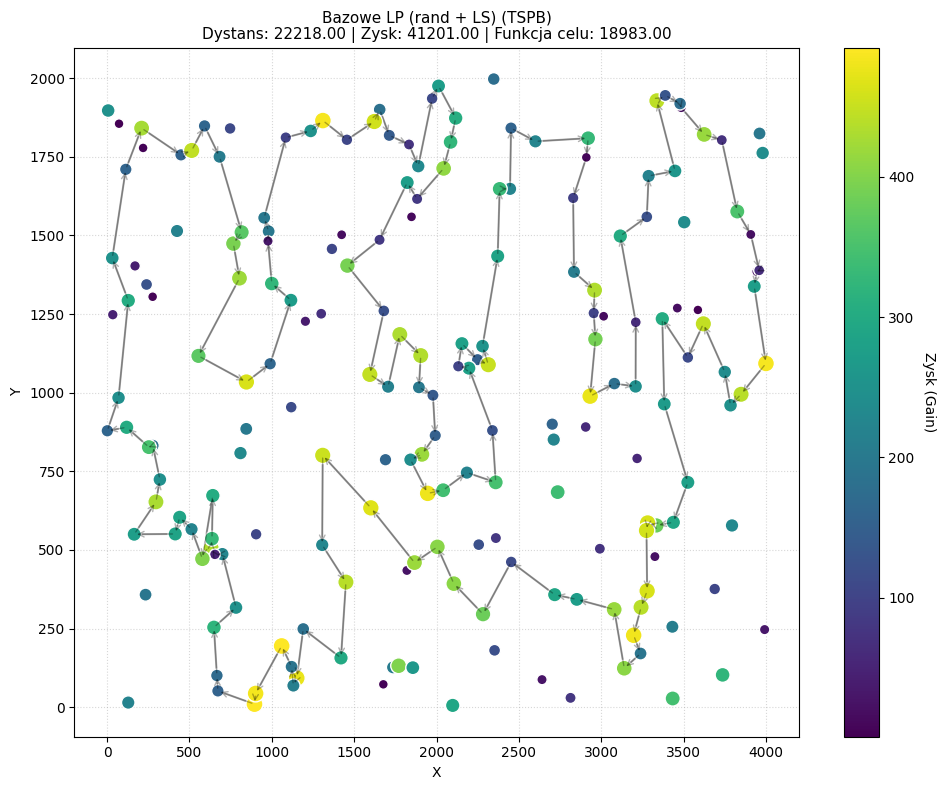

In [19]:
# === ZADANIE 6: HAE i metody porównawcze – wizualizacja i zapis do PNG ===

zad6_methods = [
    ("HAE_Op1",      "HAE Op1 + LS (wspólne podścieżki)"),
    ("HAE_Op2_LS",   "HAE Op2 + LS"),
    ("HAE_Op2_noLS", "HAE Op2 (bez LS po rekomb.)"),
    ("HAE_Op3_LS",   "HAE Op3 + LS"),
    ("HAE_Op3_noLS", "HAE Op3 (bez LS po rekomb.)"),
    ("MSLS_z6",      "MSLS"),
    ("ILS_z6",       "ILS"),
    ("LNS_z6",       "LNS (Destroy-Repair + LS)"),
    ("Heur_z6",      "Heurystyka zachłanna (2-żal)"),
    ("BaseLS_z6",    "Bazowe LP (rand + LS)"),
]
instances = ["TSPA", "TSPB"]

os.makedirs("zad6_png", exist_ok=True)

for method_id, pretty in zad6_methods:
    for inst in instances:
        json_path = f"Best_{method_id}_{inst}.csv.json"
        png_path  = f"zad6_png/Best_{method_id}_{inst}.png"
        title     = f"{pretty} ({inst})"
        plot_and_save_tsp(json_path, title, png_path, show=True)
